# 02 - Analysis: Germany's shift to electric cars

Uses the SQLite database built in notebook 01. All SQL lives in `sql/analysis_queries.sql`; this notebook runs each query and reads the result.

In [2]:
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.width", 220, "display.max_columns", 30)
con = sqlite3.connect("../data/processed/registrations.sqlite")

sql = open("../sql/analysis_queries.sql").read()
parts = re.split(r"^-- name:\s*(\w+)\s*$", sql, flags=re.M)
Q = {name: pd.read_sql(body, con) for name, body in zip(parts[1::2], parts[2::2])}
list(Q)

['monthly_fuel_mix',
 'bev_trend',
 'brand_bev_ranking_ltm',
 'brand_electrification_shift',
 'bev_by_origin',
 'top_bev_models_ltm',
 'brand_fuel_mix_latest_month']

## 1. Fuel mix by month

In [4]:
mix = Q["monthly_fuel_mix"]
mix[["month", "total", "bev_share_pct", "phev_share_pct", "hev_share_pct", "combustion_only_share_pct"]].tail(8)

,month,total,bev_share_pct,phev_share_pct,hev_share_pct,combustion_only_share_pct
16,2026-01-01,193981,22.0,11.2,30.0,36.8
17,2026-02-01,211262,21.9,11.5,28.6,37.9
18,2026-03-01,294161,24.0,10.2,29.9,35.9
19,2026-04-01,249163,25.8,11.1,28.2,34.9
20,2026-05-01,239448,25.0,11.7,28.2,35.1
21,2026-06-01,296378,28.4,10.9,28.1,32.7
22,2026-07-01,268068,29.3,11.4,27.9,31.4
23,2026-08-01,212563,32.4,12.0,27.8,27.8


## 2. Is the electric share really rising, or is it seasonality?

Compare each month with the **same month a year earlier** (`LAG(..., 12)` in SQL), because car sales have strong seasonal peaks.

In [6]:
trend = Q["bev_trend"]
trend[["month", "bev_share_pct", "bev_share_3m_avg_pct", "bev_share_yoy_change_pp", "bev_units_yoy_pct"]].tail(12)

,month,bev_share_pct,bev_share_3m_avg_pct,bev_share_yoy_change_pp,bev_units_yoy_pct
12,2025-09-01,19.3,18.9,2.8,32.0
13,2025-10-01,21.0,19.8,5.7,47.8
14,2025-11-01,22.2,20.8,7.9,58.5
15,2025-12-01,22.2,21.8,7.3,63.3
16,2026-01-01,22.0,22.2,5.4,23.8
17,2026-02-01,21.9,22.0,4.2,28.7
18,2026-03-01,24.0,22.6,7.2,66.2
19,2026-04-01,25.8,23.9,7.1,41.3
20,2026-05-01,25.0,25.0,7.1,39.3
21,2026-06-01,28.4,26.4,10.0,78.2


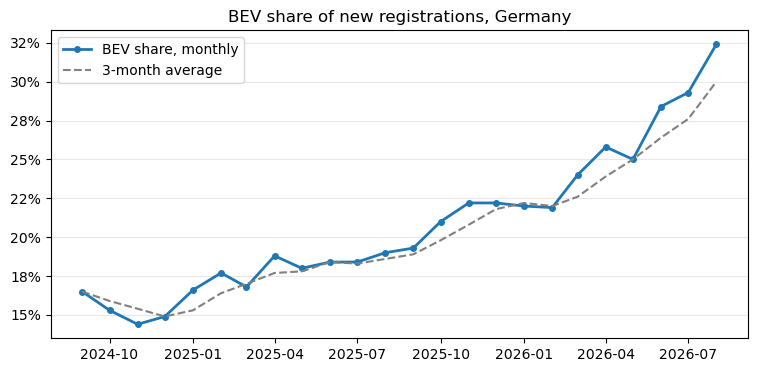

In [7]:
t = trend.copy(); t["month"] = pd.to_datetime(t["month"])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t["month"], t["bev_share_pct"], lw=2, marker="o", ms=4, label="BEV share, monthly")
ax.plot(t["month"], t["bev_share_3m_avg_pct"], lw=1.5, ls="--", color="grey", label="3-month average")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("BEV share of new registrations, Germany"); ax.legend(); ax.grid(axis="y", alpha=.3)
plt.show()

## 3. Which brands sell the electric cars?

In [9]:
Q["brand_bev_ranking_ltm"]

,rank_bev,brand,origin_group,bev,share_of_all_bev_pct,total,bev_share_in_brand_pct,plug_in_share_in_brand_pct
0,1,VW,Germany,100919,14.0,539376,18.7,28.9
1,2,SKODA,Germany,68881,9.6,246700,27.9,34.5
2,3,BMW,Germany,64576,9.0,261896,24.7,39.0
3,4,MERCEDES,Germany,52073,7.2,262919,19.8,36.2
4,5,AUDI,Germany,48987,6.8,212274,23.1,43.8
5,6,TESLA,USA,40207,5.6,40207,100.0,100.0
6,7,SEAT,Germany,36800,5.1,156914,23.5,36.9
7,8,HYUNDAI,Japan/Korea,27507,3.8,94985,29.0,34.5
8,9,FORD,USA,27123,3.8,101088,26.8,42.6
9,10,KIA,Japan/Korea,26307,3.6,63569,41.4,44.1


## 4. Who became more electric?

BEV share of each brand in the latest 6 months vs the same 6 months a year earlier. Brands need at least 3,000 registrations in both windows so that small volumes do not create noise.

In [11]:
Q["brand_electrification_shift"]

,brand,origin_group,total_prev_6m,total_now_6m,bev_share_prev_pct,bev_share_now_pct,change_pp
0,KIA,Japan/Korea,31488,35718,24.5,49.9,25.4
1,RENAULT,Other Europe,29955,38013,21.3,40.9,19.5
2,CITROEN,Other Europe,25474,28391,11.0,30.0,18.9
3,NISSAN,Japan/Korea,17419,16572,3.2,21.1,17.9
4,PEUGEOT,Other Europe,29599,32307,7.4,22.5,15.1
5,VOLVO,China,29870,26191,16.2,27.9,11.7
6,FORD,USA,56927,52388,17.0,28.6,11.6
7,MERCEDES,Germany,132241,137879,11.9,23.0,11.1
8,JEEP,Other Europe,6773,6266,4.0,14.9,10.9
9,MAZDA,Japan/Korea,20241,24978,1.4,11.2,9.8


Look at the brands at the *bottom* of this table too. A falling BEV share does not always mean a brand is going backwards. Check the plug-in share of that brand before concluding anything (next cell).

In [13]:
lat = Q["brand_fuel_mix_latest_month"]
lat[lat["brand"].isin(["BYD", "TESLA", "KIA", "VW"])]

,brand,total,bev_pct,phev_pct,hev_pct,diesel_pct,petrol_other_pct
0,VW,32233,21.8,10.2,26.7,18.0,23.4
9,KIA,6382,63.8,2.6,7.2,0.4,26.0
11,BYD,5256,34.8,65.2,0.0,0.0,0.0
20,TESLA,3034,100.0,0.0,0.0,0.0,0.0


## 5. Who is winning electric growth: German brands, Chinese brands, others?

Origin means the country of the brand's parent company (`data/reference/brand_origin.csv`, editable).

In [15]:
o = Q["bev_by_origin"]
latest = o["month"].max()
o[o["month"] == latest]

,month,origin_group,bev,share_of_month_bev_pct
138,2026-08-01,Germany,32733,47.5
139,2026-08-01,Other Europe,11805,17.1
140,2026-08-01,Japan/Korea,9014,13.1
141,2026-08-01,China,8267,12.0
142,2026-08-01,USA,6295,9.1
143,2026-08-01,Other / JV,816,1.2


## 6. Best-selling electric models

In [17]:
Q["top_bev_models_ltm"]

,rank_bev,brand,model,bev_registrations
0,1,SKODA,ELROQ,38637
1,2,VW,ID.3,33985
2,3,VW,ID.7,32205
3,4,SKODA,ENYAQ,30124
4,5,TESLA,MODEL Y,26109
5,6,BMW,X1,22924
6,7,VW,"ID.4, ID.5",22771
7,8,MERCEDES,CLA-KLASSE,21132
8,9,AUDI,A6,19583
9,10,MINI,MINI,18925


## 7. Headline numbers (computed, not typed)

In [19]:
m = Q["monthly_fuel_mix"].copy()
m["month"] = pd.to_datetime(m["month"])
end = m["month"].max()
now = m[(m["month"].dt.year == end.year)]
prev = m[(m["month"].dt.year == end.year - 1) & (m["month"].dt.month <= end.month)]
print(f"Latest month: {end:%b %Y}")
print(f"BEV share Jan-{end:%b} {end.year}: {100*now['bev'].sum()/now['total'].sum():.1f}%  vs  {100*prev['bev'].sum()/prev['total'].sum():.1f}% a year earlier")
print(f"BEV units: {100*(now['bev'].sum()/prev['bev'].sum()-1):+.0f}%   all registrations: {100*(now['total'].sum()/prev['total'].sum()-1):+.1f}%")

Latest month: Aug 2026
BEV share Jan-Aug 2026: 26.2%  vs  18.0% a year earlier
BEV units: +53%   all registrations: +4.8%


## Limits of this analysis

- Registrations are not sales: fleet, dealer and self-registrations are counted, and KBA can revise a month later.
- `Hybrid (no plug-in)` includes 48V mild hybrids, because KBA counts them as hybrids.
- `Petrol & other` is derived (total minus the other four categories).
- Brand origin uses the parent company and involves judgement (for example Volvo counts as China because of Geely).
- 24 months is enough to see the trend, but not to say anything about long-term seasonality.